<a href="https://colab.research.google.com/github/Taran-Gupta/DS4002_Project2/blob/main/Scripts/MI2_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load the data
data = pd.read_csv("unemployment_by_month.csv", index_col = 0)

data.head(5)

,LNS14000036,LNS14000089,LNS14000091,LNS14000093,LNS14024230
observation_date,,,,,
1948-01-01,5.8,3.0,2.0,2.2,2.9
1948-02-01,6.3,3.3,2.5,2.8,3.1
1948-03-01,7.6,2.9,2.7,2.6,3.0
1948-04-01,6.8,3.4,2.9,2.6,3.0
1948-05-01,6.6,3.0,2.6,2.4,3.1


In [ ]:
# Rename the columns to be more descriptive
data = data.rename(columns = {"observation_date": "date", "LNS14000036": "20-24", "LNS14000089": "25-34", "LNS14000091": "35-44", "LNS14000093": "45-54", "LNS14024230": "55 & Over"})

data.head(5)


,20-24,25-34,35-44,45-54,55 & Over
observation_date,,,,,
1948-01-01,5.8,3.0,2.0,2.2,2.9
1948-02-01,6.3,3.3,2.5,2.8,3.1
1948-03-01,7.6,2.9,2.7,2.6,3.0
1948-04-01,6.8,3.4,2.9,2.6,3.0
1948-05-01,6.6,3.0,2.6,2.4,3.1


In [ ]:
# Dropping all dates before 2004.
data = data[data.index >= "2004-01-01"]


# Making it quarterly so that it matches net worth data. Setting the resample to start of quarter.
data.index = pd.to_datetime(data.index)
data_quarterly = data.resample("QS").mean()

data_quarterly.head(30)

,20-24,25-34,35-44,45-54,55 & Over
observation_date,,,,,
2004-01-01,9.666667,5.766667,4.600000,4.000000,3.733333
2004-04-01,9.566667,5.400000,4.433333,3.933333,3.966667
2004-07-01,9.233333,5.366667,4.366667,3.666667,3.633333
2004-10-01,9.200000,5.500000,4.033333,3.700000,3.633333
2005-01-01,9.566667,5.233333,4.066667,3.500000,3.533333
2005-04-01,8.800000,5.166667,3.833333,3.400000,3.300000
2005-07-01,8.500000,5.133333,3.700000,3.466667,3.400000
2005-10-01,8.333333,5.000000,3.866667,3.533333,3.200000
2006-01-01,8.200000,4.866667,3.700000,3.200000,2.866667


<Axes: xlabel='observation_date'>

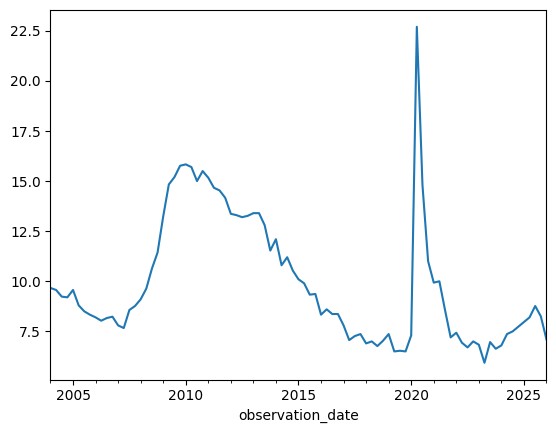

In [ ]:
# Plotting the unemployment rate for ages 20-24 over time.
data_quarterly["20-24"].plot()

Text(0.5, 1.0, 'Unemployment Rate by Age Group')

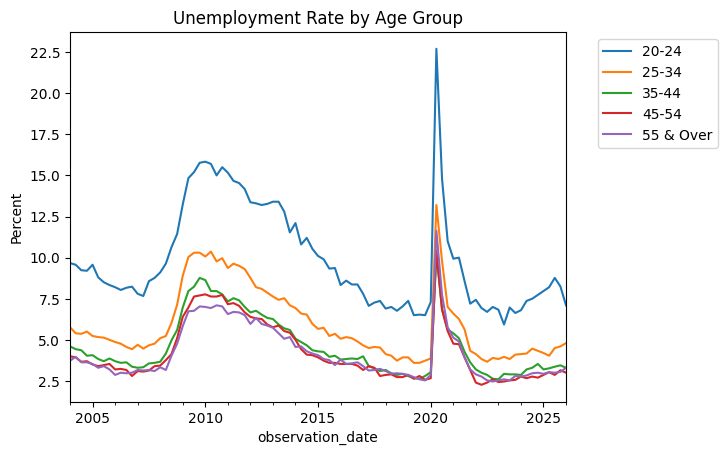

In [ ]:
# Plotting the unemployment rate for all age groups over time
data_quarterly.plot()
plt.legend(loc = "upper left", bbox_to_anchor = (1.05, 1.0))
plt.ylabel("Percent")
plt.title("Unemployment Rate by Age Group")

In [ ]:
# summary statistics for the data
data_quarterly.describe()

,20-24,25-34,35-44,45-54,55 & Over
count,89.000000,89.000000,89.000000,89.000000,89.000000
mean,9.884082,5.931086,4.571723,4.209551,4.163483
std,3.158428,2.163271,1.781758,1.761936,1.662307
min,5.933333,3.600000,2.600000,2.266667,2.466667
25%,7.366667,4.333333,3.266667,2.866667,3.000000
50%,8.766667,5.133333,3.866667,3.533333,3.466667
75%,11.533333,7.100000,5.600000,5.433333,5.133333
max,22.700000,13.200000,10.233333,10.433333,11.633333


array([[<Axes: title={'center': '20-24'}>,
        <Axes: title={'center': '25-34'}>],
       [<Axes: title={'center': '35-44'}>,
        <Axes: title={'center': '45-54'}>],
       [<Axes: title={'center': '55 & Over'}>, <Axes: >]], dtype=object)

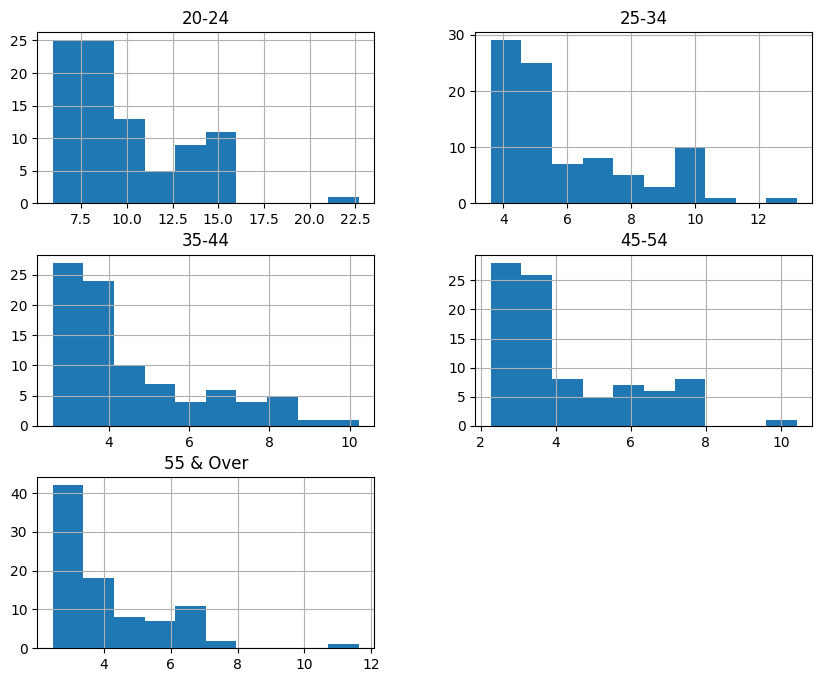

In [ ]:
# Plotting histograms for each age group to see the distribution of unemployment rates
data_quarterly.hist(figsize = (10,8))

In [ ]:
# Correlation matrix for the data
data_quarterly.corr()

,20-24,25-34,35-44,45-54,55 & Over
20-24,1.000000,0.983206,0.977490,0.981172,0.973836
25-34,0.983206,1.000000,0.991697,0.992067,0.977885
35-44,0.977490,0.991697,1.000000,0.990642,0.970392
45-54,0.981172,0.992067,0.990642,1.000000,0.981737
55 & Over,0.973836,0.977885,0.970392,0.981737,1.000000
